# Módulo 10 atividade 1

Uma instituição financeira quer conhecer melhor o perfil de renda de seus novos clientes para diversos fins, por exemplo, melhor dimensionar o limite de cartões de crédito dos novos clientes, sem necessariamente solicitar olerites ou documentações que impactem na experiência do seu cliente.

Para isto, conduziu um estudo com alguns clientes, comprovando suas rendas através de olerites e outros documentos, e pretende construir um modelo preditivo para esta renda com base em algumas variáveis que já possui em seu banco de dados.

As variáveis são intuitivas - note que há uma variável 'index' que é um identificador do cliente e que em geral o ```read_csv``` do pandas coloca também uma variável sequencial.

Estes dados estão no arquivo ```previsao_de_renda.csv```. Carregue-o em um *dataframe*.

1) Avalie a estrutura de correlação das variáveis quantitativas através de um gráfico de "matriz de dispersão" e através da avaliação gráfica da matriz de correlações. Veja se você identifica algum padrão interessante ou que te faça sentido.

In [2]:
# Vamos carregar as bibliotecas necessárias para a nossa análise:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
# Agora temos que carregar os dados:
df = pd.read_csv("previsao_de_renda.csv")

In [4]:
# Vamos visualizar e verificar se está tudo bem com o nosso DataFrame:
df.head(5)

,Unnamed: 0,data_ref,index,sexo,posse_de_veiculo,posse_de_imovel,qtd_filhos,tipo_renda,educacao,estado_civil,tipo_residencia,idade,tempo_emprego,qt_pessoas_residencia,mau,renda
0,0,2015-01-01,8682,F,False,True,1,Assalariado,Secundário,Casado,Casa,36,3.575342,3.0,False,3369.24
1,1,2015-01-01,12830,M,True,True,0,Empresário,Secundário,Casado,Casa,42,0.860274,2.0,False,6096.14
2,2,2015-01-01,2885,M,True,True,2,Assalariado,Superior completo,Casado,Casa,31,8.065753,4.0,False,5658.98
3,3,2015-01-01,16168,F,True,False,0,Empresário,Secundário,Casado,Casa,50,1.208219,2.0,False,7246.69
4,4,2015-01-01,12438,M,False,False,0,Assalariado,Secundário,Casado,Casa,52,13.873973,2.0,False,4017.37


### Vamos então correlacionar as variáveis quantitativas com a coluna "renda" para verificar e avaliar qual terá a maior correlação com a renda:

In [5]:
# Vamos construir um DataFrame usando a coluna "renda" com a primeira variável qualitativa "qtd_filhos" 
df1 = df[["renda","qtd_filhos"]]

# Mostramos o DataFrame para visualização e verificação:
df1.head(5)

,renda,qtd_filhos
0,3369.24,1
1,6096.14,0
2,5658.98,2
3,7246.69,0
4,4017.37,0


### Primeiro, vamos fazer um gráfico de dispersão relacionando a quantidade de filhos (eixo X) com a renda do cliente (eixo y):

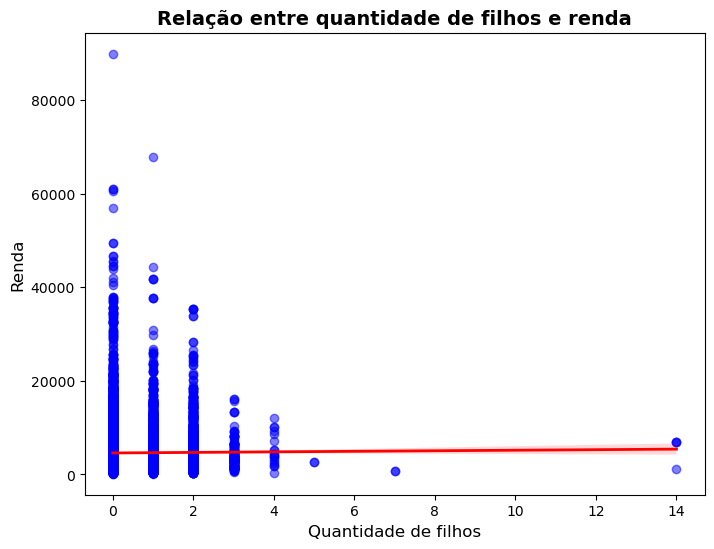

In [6]:
# Vamos definir o tamanho da figura em que será alocado o nosso gráfico:
plt.figure( figsize = (8, 6) )

# Gráfico de dispersão com linha de regressão:
sns.regplot(
    x = "qtd_filhos",
    y = "renda",
    data = df1,
    # definimos a cor dos pontos e a opacidade dos mesmos:
    scatter_kws={'color': 'blue', 'alpha': 0.5},
    # determina que a cor da linha de regressão seja vermelha e o tamanho de seu comprimento:
    line_kws={'color': 'red', 'linewidth': 2}
    
)

# Definimos os rótulos dos eixos e o título do gráfico:
plt.title("Relação entre quantidade de filhos e renda", fontsize = 14, fontweight = 'bold')
plt.xlabel("Quantidade de filhos", fontsize = 12)
plt.ylabel("Renda", fontsize = 12)

# E mostramos o gráfico:
plt.show()

In [7]:
# Vamos calcular a matriz de correlação:
df1.corr()

,renda,qtd_filhos
renda,1.000000,0.009567
qtd_filhos,0.009567,1.000000


### Pelo gráfico de dispersão, podemos dizer que não há relação alguma entre a quantidade de filhos e renda, mostrando a linha de regressão praticamente na horizontal.
### Para reforçar esta percepção, a matriz de correlação mostra um valor próximo de zero entre as variáveis quantidade de filhos e renda, corroborando com o diagnóstico de que não há relação entre estas variáveis.

## Vamos agora analisar se há uma relação entre a idade do cliente e a renda.

In [8]:
# Vamos construir um DataFrame usando a coluna "renda" com a primeira variável qualitativa "qtd_filhos" 
df2 = df[["renda","idade"]]

# Mostramos o DataFrame para visualização e verificação:
df2.head(5)

,renda,idade
0,3369.24,36
1,6096.14,42
2,5658.98,31
3,7246.69,50
4,4017.37,52


### Primeiro, vamos fazer um gráfico de dispersão relacionando a idade (eixo X) com a renda do cliente (eixo y):

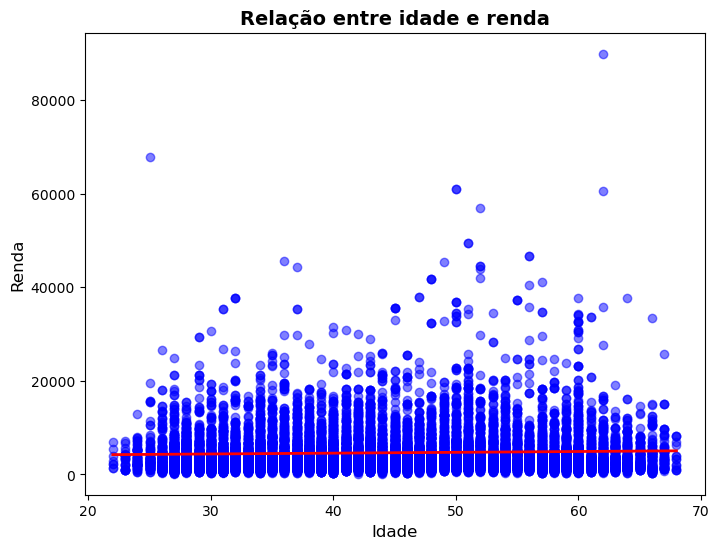

In [9]:
# Vamos definir o tamanho da figura em que será alocado o nosso gráfico:
plt.figure( figsize = (8, 6) )

# Gráfico de dispersão com linha de regressão:
sns.regplot(
    x = "idade",
    y = "renda",
    data = df2,
    # definimos a cor dos pontos e a opacidade dos mesmos:
    scatter_kws={'color': 'blue', 'alpha': 0.5},
    # determina que a cor da linha de regressão seja vermelha e o tamanho de seu comprimento:
    line_kws={'color': 'red', 'linewidth': 2}
    
)

# Definimos os rótulos dos eixos e o título do gráfico:
plt.title("Relação entre idade e renda", fontsize = 14, fontweight = 'bold')
plt.xlabel("Idade", fontsize = 12)
plt.ylabel("Renda", fontsize = 12)

# E mostramos o gráfico:
plt.show()

### Agora vamos calcular a matriz de correlação entre as duas variáveis:

In [10]:
df2.corr()

,renda,idade
renda,1.00000,0.04257
idade,0.04257,1.00000


# Agora vamos analisar se há uma correlação entre o tempo de emprego e a renda.

In [11]:
# Vamos construir um DataFrame com as features necessárias para a análise:
df3 = df[['renda','tempo_emprego']]

# Mostramos o DataFrame para visualização e verificação:
df3.head(5)

,renda,tempo_emprego
0,3369.24,3.575342
1,6096.14,0.860274
2,5658.98,8.065753
3,7246.69,1.208219
4,4017.37,13.873973


### Primeiro, vamos fazer um gráfico de dispersão relacionando o tempo de emprego (eixo X) com a renda do cliente (eixo y):

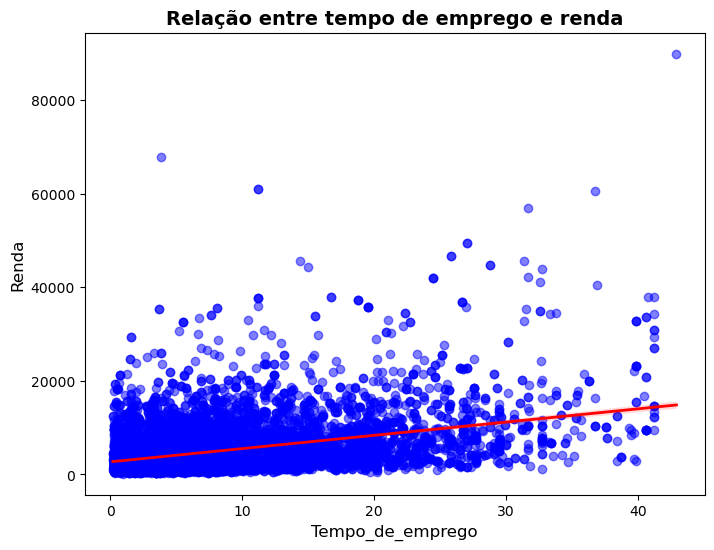

In [12]:
# Vamos definir o tamanho da figura em que será alocado o nosso gráfico:
plt.figure( figsize = (8, 6) )

# Gráfico de dispersão com linha de regressão:
sns.regplot(
    x = "tempo_emprego",
    y = "renda",
    data = df3,
    # definimos a cor dos pontos e a opacidade dos mesmos:
    scatter_kws={'color': 'blue', 'alpha': 0.5},
    # determina que a cor da linha de regressão seja vermelha e o tamanho de seu comprimento:
    line_kws={'color': 'red', 'linewidth': 2}  
)

# Definimos os rótulos dos eixos e o título do gráfico:
plt.title("Relação entre tempo de emprego e renda", fontsize = 14, fontweight = 'bold')
plt.xlabel("Tempo_de_emprego", fontsize = 12)
plt.ylabel("Renda", fontsize = 12)

# E mostramos o gráfico:
plt.show()

In [13]:
# Vamos então calcular a matriz de correlação entre as duas variáveis:
df3.corr()

,renda,tempo_emprego
renda,1.000000,0.394235
tempo_emprego,0.394235,1.000000


### Podemos ver que a linha de regressão tem uma tendência crescente, quanto mais tempo de emprego, maior é a renda. Isto é confirmado pela matriz de correlação entre as duas vairáveis que chega próxima a 0.4.

# Vamos estudar agora se há uma correlação entre a renda e a quantidade de pessoas que vivem na residência:

In [14]:
# Vamos construir um DataFrame com as features necessárias para a análise:
df4 = df[['renda','qt_pessoas_residencia']]

# Mostramos o DataFrame para visualização e verificação:
df4.head(5)

,renda,qt_pessoas_residencia
0,3369.24,3.0
1,6096.14,2.0
2,5658.98,4.0
3,7246.69,2.0
4,4017.37,2.0


### Primeiro, vamos fazer um gráfico de dispersão relacionando a quantidade de pessoas que moram na residência (eixo X) com a renda do cliente (eixo y):

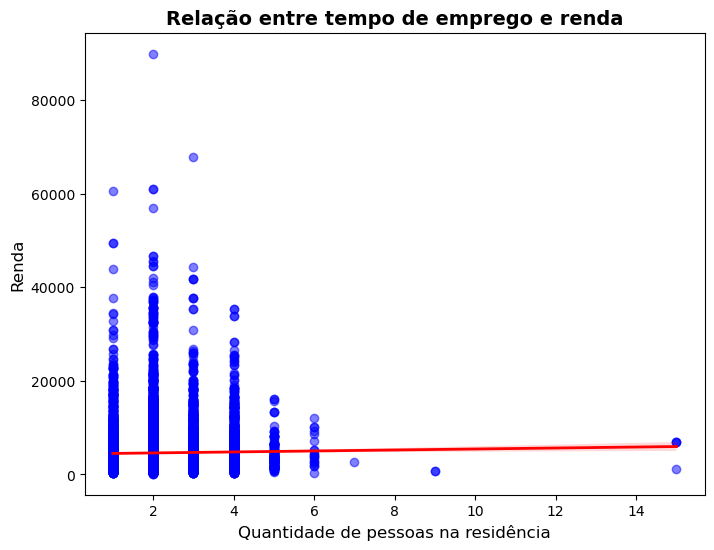

In [15]:
# Vamos definir o tamanho da figura em que será alocado o nosso gráfico:
plt.figure( figsize = (8, 6) )

# Gráfico de dispersão com linha de regressão:
sns.regplot(
    x = "qt_pessoas_residencia",
    y = "renda",
    data = df4,
    # definimos a cor dos pontos e a opacidade dos mesmos:
    scatter_kws={'color': 'blue', 'alpha': 0.5},
    # determina que a cor da linha de regressão seja vermelha e o tamanho de seu comprimento:
    line_kws={'color': 'red', 'linewidth': 2}  
)

# Definimos os rótulos dos eixos e o título do gráfico:
plt.title("Relação entre tempo de emprego e renda", fontsize = 14, fontweight = 'bold')
plt.xlabel("Quantidade de pessoas na residência", fontsize = 12)
plt.ylabel("Renda", fontsize = 12)

# E mostramos o gráfico:
plt.show()

### Agora vamos calcular a matriz de correlação entre as duas variáveis:

In [16]:
df4.corr()

,renda,qt_pessoas_residencia
renda,1.000000,0.020977
qt_pessoas_residencia,0.020977,1.000000


In [17]:
df.dtypes

Unnamed: 0                 int64
data_ref                  object
index                      int64
sexo                      object
posse_de_veiculo            bool
posse_de_imovel             bool
qtd_filhos                 int64
tipo_renda                object
educacao                  object
estado_civil              object
tipo_residencia           object
idade                      int64
tempo_emprego            float64
qt_pessoas_residencia    float64
mau                         bool
renda                    float64
dtype: object

### 2) Avalie um gráfico de dispersão (*scatterplot*) específico para as duas variáveis mais correlacionadas com *renda*.

### As duas variáveis mais correlacionadas com a renda são, em ordem crescente de valor: idade e tempo de serviço. Primeiro vamos analisar o gráfico de dispersão para a variável idade.

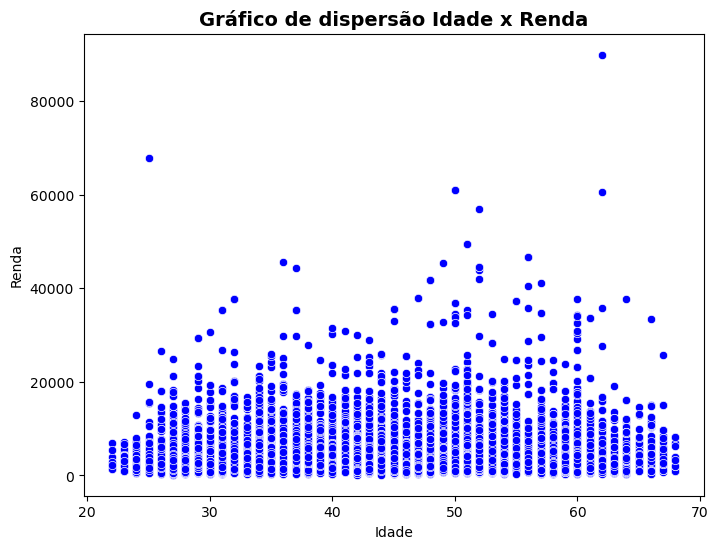

In [24]:
# Vamos definir o tamanho da figura em que será plotado o nosso gráfico:
plt.figure(figsize=(8,6))

# Definimos os parãmetros, ou seja, as variáveis, o DataFrame e a cor de nosso gráfico:
sns.scatterplot(x = "idade", y = "renda", data = df2, color = "blue")

# Aqui determinamos os título e os rótulos de nosso gráfico de dispersão: 
plt.title("Gráfico de dispersão Idade x Renda", fontsize = 14, fontweight = "bold")
plt.xlabel("Idade")
plt.ylabel("Renda")

plt.show()

### Agora vamos fazer o gráfico de dispersão que relaciona o tempo de emprego com a renda do cliente:

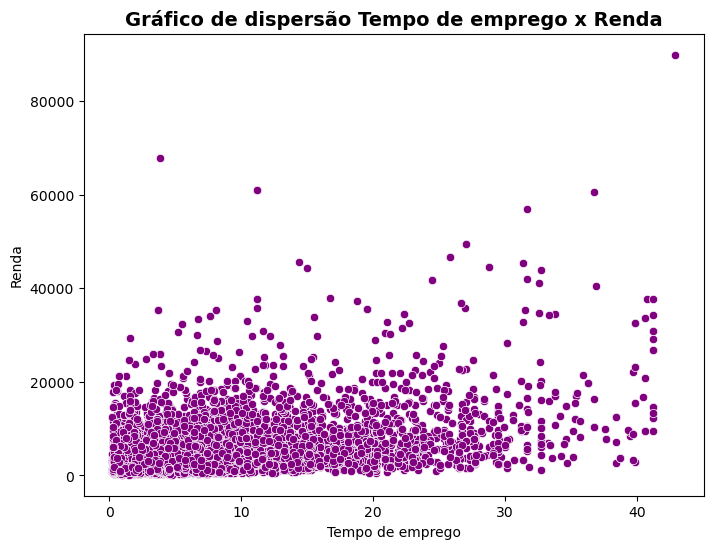

In [23]:
# Vamos definir o tamanho da figura em que será plotado o nosso gráfico:
plt.figure(figsize=(8,6))

# Definimos os parãmetros, ou seja, as variáveis, o DataFrame e a cor de nosso gráfico:
sns.scatterplot(x = "tempo_emprego", y = "renda", data = df3, color = "purple")

# Aqui determinamos os título e os rótulos de nosso gráfico de dispersão: 
plt.title("Gráfico de dispersão Tempo de emprego x Renda", fontsize=14, fontweight="bold")
plt.xlabel("Tempo de emprego")
plt.ylabel("Renda")

plt.show()

### 3) Na sua opinião, há outliers na variável renda?

### Analisando o primeiro gráfico de dispersão, podemos perceber que há uma pessoa jovem, com idade entre 20 e 30 anos que possui uma renda alta, maior que aquelas mais velhas, inclusive. E há uma pessoa mais velha que tem uma renda que é mais alta que todas as demais. Isto me faz ter a opinião que há outliers.

### No segundo gráfico, temos um padrão semelhante. Há uma pessoa que têm um tempo pequeno na empresa com uma renda alta e uma pessoa com muito tempo na empresa com uma renda maior que todas as outras pessoas, reafirmando a presença de outliers na base de dados.

### 4) Calcule o logaritmo da variável renda e repita a sequência de análise

In [26]:
# Vamos fazer uma cópia do DataFrame df2 para ajustar a variável renda pelo cálculo do logarritmo da renda:
df2_log = df2.copy()

# Criamos uma nova coluna chamada "log_renda" em que calculamos os valores dos logaritmos neperianos dos valores da coluna "y" segundo a 
# função da biblioteca Numpy "np.log()", em que passamos como parâmetro os valores da coluna "renda" do DataFrame "df2_log":
df2_log['log_renda'] = np.log(df2_log['renda'])

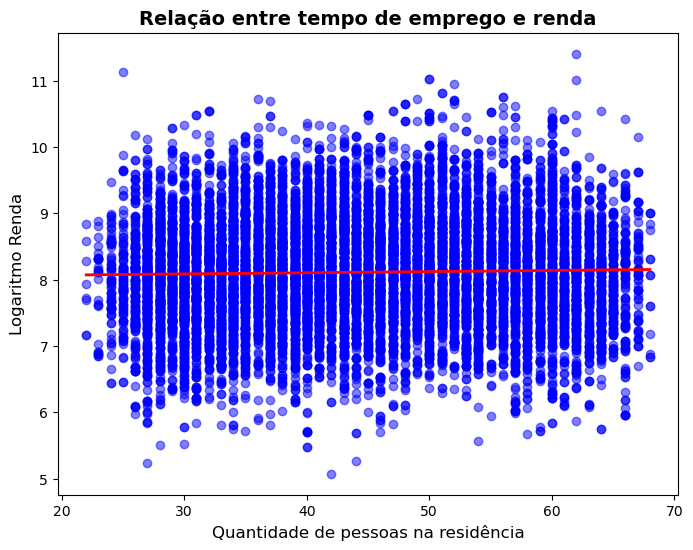

In [28]:
# Vamos definir o tamanho da figura em que será alocado o nosso gráfico:
plt.figure( figsize = (8, 6) )

# Gráfico de dispersão com linha de regressão:
sns.regplot(
    x = "idade",
    y = "log_renda",
    data = df2_log,
    # definimos a cor dos pontos e a opacidade dos mesmos:
    scatter_kws={'color': 'blue', 'alpha': 0.5},
    # determina que a cor da linha de regressão seja vermelha e o tamanho de seu comprimento:
    line_kws={'color': 'red', 'linewidth': 2}  
)

# Definimos os rótulos dos eixos e o título do gráfico:
plt.title("Relação entre tempo de emprego e renda", fontsize = 14, fontweight = 'bold')
plt.xlabel("Quantidade de pessoas na residência", fontsize = 12)
plt.ylabel("Logaritmo Renda", fontsize = 12)

# E mostramos o gráfico:
plt.show()

In [29]:
df2_log.corr()

,renda,idade,log_renda
renda,1.000000,0.042570,0.835734
idade,0.042570,1.000000,0.024712
log_renda,0.835734,0.024712,1.000000


In [30]:
# Vamos fazer uma cópia do DataFrame df2 para ajustar a variável renda pelo cálculo do logarritmo da renda:
df3_log = df3.copy()

# Criamos uma nova coluna chamada "log_renda" em que calculamos os valores dos logaritmos neperianos dos valores da coluna "y" segundo a 
# função da biblioteca Numpy "np.log()", em que passamos como parâmetro os valores da coluna "renda" do DataFrame "df3_log":
df3_log['log_renda'] = np.log(df3_log['renda'])

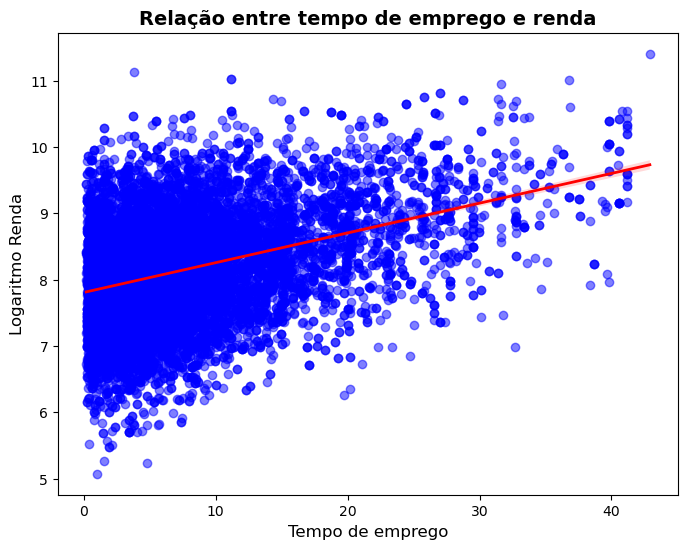

In [32]:
# Vamos definir o tamanho da figura em que será alocado o nosso gráfico:
plt.figure( figsize = (8, 6) )

# Gráfico de dispersão com linha de regressão:
sns.regplot(
    x = "tempo_emprego",
    y = "log_renda",
    data = df3_log,
    # definimos a cor dos pontos e a opacidade dos mesmos:
    scatter_kws={'color': 'blue', 'alpha': 0.5},
    # determina que a cor da linha de regressão seja vermelha e o tamanho de seu comprimento:
    line_kws={'color': 'red', 'linewidth': 2}  
)

# Definimos os rótulos dos eixos e o título do gráfico:
plt.title("Relação entre tempo de emprego e renda", fontsize = 14, fontweight = 'bold')
plt.xlabel("Tempo de emprego", fontsize = 12)
plt.ylabel("Logaritmo Renda", fontsize = 12)

# E mostramos o gráfico:
plt.show()

In [33]:
df3_log.corr()

,renda,tempo_emprego,log_renda
renda,1.000000,0.394235,0.835734
tempo_emprego,0.394235,1.000000,0.379556
log_renda,0.835734,0.379556,1.000000


### 5) A aplicação do LOG você acha que melhorou ou piorou a análise?

### A aplicação do LOG, na minha opinião, piorou a análise pois os valores da correação diminuíram e os gráficos perderam a informação dos outliers. Ou seja, aplicar o logaritmopode fazer com que informações importantes